## Klasifikasi Berita dengan Vektor Skip-gram dan Naive Bayes



## 1. Import Library

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)

# Skip-gram memakai Gensim (Word2Vec dengan sg=1), sama seperti skipgram.ipynb.
try:
    from gensim.models import Word2Vec
    GENSIM_TERSEDIA = True
    print("Gensim ditemukan -> Skip-gram memakai gensim.models.Word2Vec")
except ImportError:
    GENSIM_TERSEDIA = False
    print("Gensim tidak ditemukan -> memakai implementasi Skip-gram (negative sampling) berbasis NumPy "
          "pada sel berikutnya. Jika ingin memakai Gensim: pip install gensim")

Gensim tidak ditemukan -> memakai implementasi Skip-gram (negative sampling) berbasis NumPy pada sel berikutnya. Jika ingin memakai Gensim: pip install gensim


### Implementasi cadangan Skip-gram (hanya aktif jika Gensim tidak terpasang)

Jika Gensim **sudah** terpasang, sel di bawah ini tidak melakukan apa-apa. Jika belum, sel ini mendefinisikan kelas `Word2Vec` sederhana berbasis NumPy yang meniru pemakaian Gensim (`Word2Vec(sentences, vector_size, window, min_count, sg=1, epochs, seed)` dan `model.wv[kata]`), yaitu **Skip-gram dengan negative sampling**: untuk setiap pasangan (kata target, kata konteks), model dilatih agar skor pasangan asli tinggi dan skor pasangan acak (negatif) rendah. Setelah pelatihan, vektor kata diambil dari matriks bobot input.

In [2]:
if not GENSIM_TERSEDIA:

    class _WordVectors:
        def __init__(self, index_to_key, vectors):
            self.index_to_key = index_to_key
            self.key_to_index = {w: i for i, w in enumerate(index_to_key)}
            self.vectors = vectors

        def __getitem__(self, kata):
            return self.vectors[self.key_to_index[kata]]

        def __contains__(self, kata):
            return kata in self.key_to_index

        def most_similar(self, kata, topn=3):
            v = self[kata]
            norma = np.linalg.norm(self.vectors, axis=1) * np.linalg.norm(v) + 1e-12
            sim = (self.vectors @ v) / norma
            urut = np.argsort(-sim)
            hasil = [(self.index_to_key[i], float(sim[i])) for i in urut
                     if self.index_to_key[i] != kata]
            return hasil[:topn]

    class Word2Vec:
        """Skip-gram + negative sampling (pengganti gensim.models.Word2Vec(sg=1))."""
        def __init__(self, sentences, vector_size=100, window=5, min_count=1, sg=1,
                     epochs=5, negative=5, alpha=0.025, min_alpha=0.0001, seed=1, workers=1):
            assert sg == 1, "Implementasi cadangan ini hanya untuk Skip-gram (sg=1)"
            rng = np.random.default_rng(seed)
            hitung = Counter(w for s in sentences for w in s)
            vocab = [w for w, c in hitung.most_common() if c >= min_count]
            idx = {w: i for i, w in enumerate(vocab)}
            V, d = len(vocab), vector_size

            W_in = (rng.random((V, d)) - 0.5) / d      # vektor kata (target)
            W_out = np.zeros((V, d))                   # vektor konteks

            # distribusi negative sampling: frekuensi^0.75
            p = np.array([hitung[w] for w in vocab], dtype=float) ** 0.75
            p /= p.sum()

            # bentuk seluruh pasangan (target, konteks)
            pasangan = []
            for s in sentences:
                ids = [idx[w] for w in s if w in idx]
                for i, t in enumerate(ids):
                    for j in range(max(0, i - window), min(len(ids), i + window + 1)):
                        if j != i:
                            pasangan.append((t, ids[j]))
            pasangan = np.array(pasangan)
            n = len(pasangan)

            sigmoid = lambda x: 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))
            label = np.zeros(negative + 1); label[0] = 1.0

            for ep in range(epochs):
                lr = alpha - (alpha - min_alpha) * ep / max(1, epochs - 1)
                urutan = rng.permutation(n)
                negatif = rng.choice(V, size=(n, negative), p=p)
                for k in urutan:
                    t, o = pasangan[k]
                    target = np.concatenate(([o], negatif[k]))
                    v = W_in[t]
                    U = W_out[target]
                    g = (label - sigmoid(U @ v)) * lr
                    W_in[t] += g @ U
                    W_out[target] += np.outer(g, v)

            self.vector_size = d
            self.wv = _WordVectors(vocab, W_in)

## 2. Memuat Data Hasil Crawling

Data yang dipakai adalah `df_berita_hasil_crawling.csv` (hasil dari `crawlingdata.ipynb`). Kolom **`Judul Berita`** menjadi bahan teks, dan kolom **`Kategori`** menjadi **label kelas** untuk klasifikasi.

In [3]:
CSV_PATH = 'df_berita_hasil_crawling.csv'

df_berita = pd.read_csv(CSV_PATH, index_col='No')
print(f"Berhasil memuat df_berita dari '{CSV_PATH}'")
print("Jumlah data berita:", len(df_berita))
print("Jumlah kategori unik:", df_berita['Kategori'].nunique())
print("\nDistribusi kategori:")
print(df_berita['Kategori'].value_counts())

df_berita.head()

Berhasil memuat df_berita dari 'df_berita_hasil_crawling.csv'
Jumlah data berita: 200
Jumlah kategori unik: 2

Distribusi kategori:
Kategori
health    100
sport     100
Name: count, dtype: int64


,Judul Berita,Tautan,Kategori
No,,,
1,"Susul Italia, Denmark Juga Di-lockdown Imbas Virus Corona",https://health.detik.com/berita-detikhealth/d-4935778/susul-italia-denmark-juga-di-lockdown-imbas-virus-corona,health
2,Mungkinkah Virus Corona Aktif Lagi Setelah Pasien Dinyatakan Sembuh?,https://health.detik.com/berita-detikhealth/d-4978767/mungkinkah-virus-corona-aktif-lagi-setelah-pasien-dinyatakan-sembuh,health
3,"Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh dan 1.923 Meninggal",https://health.detik.com/berita-detikhealth/d-5046688/sebaran-kasus-corona-ri-9-juni-11414-sembuh-dan-1923-meninggal,health
4,"Kisah Pasien 03, Buka-bukaan Awal Tertular Virus Corona Sampai Sembuh",https://health.detik.com/berita-detikhealth/d-4944235/kisah-pasien-03-buka-bukaan-awal-tertular-virus-corona-sampai-sembuh,health
5,4 Variasi Seks Ketika Penetrasi Biasa Terasa Menyiksa,https://health.detik.com/sexual-health/d-4947758/4-variasi-seks-ketika-penetrasi-biasa-terasa-menyiksa,health


## 3. Preprocessing Teks

Tahapannya sama dengan `crawlingdata2.ipynb`: *case folding* → *cleaning* → *tokenizing* → *stopword removal* → *stemming* (Sastrawi jika terpasang, jika tidak memakai stemmer sederhana cadangan). Bedanya, selain `teks_bersih` (string), disimpan juga **`token`** (list kata **berurutan**), karena Skip-gram membutuhkan urutan kata untuk menentukan konteks.

In [4]:
try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

    daftar_stopword = set(StopWordRemoverFactory().get_stop_words())
    stemmer = StemmerFactory().create_stemmer()
    SASTRAWI_TERSEDIA = True
    print("Sastrawi berhasil dimuat. Stopword removal & stemming menggunakan Sastrawi.")

except ImportError:
    SASTRAWI_TERSEDIA = False
    _PREFIXES = ['meng', 'meny', 'men', 'mem', 'me', 'peng', 'peny', 'pen', 'pem', 'pe',
                 'ber', 'ter', 'di', 'ke', 'se']
    _SUFFIXES = ['kan', 'an', 'i', 'nya', 'lah', 'kah', 'ku', 'mu']

    class SimpleStemmer:
        def stem(self, kata):
            asal = kata
            for sfx in sorted(_SUFFIXES, key=len, reverse=True):
                if kata.endswith(sfx) and len(kata) - len(sfx) >= 3:
                    kata = kata[: -len(sfx)]
                    break
            for pfx in sorted(_PREFIXES, key=len, reverse=True):
                if kata.startswith(pfx) and len(kata) - len(pfx) >= 3:
                    kata = kata[len(pfx):]
                    break
            return kata if len(kata) >= 3 else asal

    stemmer = SimpleStemmer()
    daftar_stopword = set("""
    yang untuk pada ke para namun menurut antara dia dua ia seperti jika jika sehingga kembali dan
    tidak ini karena kepada oleh saat harus sementara setelah belum kami sekitar bagi serta di dari
    dalam akan bahwa juga atau itu adalah dengan sebagai secara ada saja sudah dapat telah bisa
    tersebut namun hal sebuah suatu masih agar lebih tak kata orang ya jadi cara satu tahun apa
    para hingga sebagai sebelum bagaimana pun terhadap sedang sekali beberapa terkait bahkan sampai
    banyak lagi juga hanya per soal maupun mereka kita kamu saya anda dirinya mengapa
    """.split())
    print("Sastrawi tidak ditemukan (pip install Sastrawi untuk hasil terbaik).")


def preprocessing_token(teks: str):
    """case folding -> cleaning -> tokenizing -> stopword removal -> stemming.
    Mengembalikan list token (urutan kata dipertahankan)."""
    teks = teks.lower()
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    tokens = [t for t in teks.split() if t not in daftar_stopword and len(t) > 1]
    return [stemmer.stem(t) for t in tokens]


# --- Membentuk kolom 'token' (stem) -----------------------------------------
# Prioritas 1: Sastrawi (sama persis dengan crawlingdata2.ipynb).
# Prioritas 2: bila Sastrawi tidak terpasang tetapi tfidf_hasil.csv (hasil Tahap 2 yang
#              sudah distem oleh Sastrawi) tersedia, bentuk stem tiap kata dicocokkan ke
#              kolom kata unik pada baris dokumen yang sama, sehingga hasilnya sama dengan
#              hasil Sastrawi Tahap 2 dan urutan kata tetap terjaga.
# Prioritas 3: stemmer sederhana (fallback) dari sel di atas.
from difflib import SequenceMatcher

def token_dari_tfidf(judul, stem_dokumen):
    teks = re.sub(r'[^a-z\s]', ' ', judul.lower())
    tokens = [t for t in teks.split() if len(t) > 1]
    stem_dokumen = set(stem_dokumen)
    hasil = [t if t in stem_dokumen else None for t in tokens]        # cocok persis
    sisa = stem_dokumen - {h for h in hasil if h}
    for i, t in enumerate(tokens):                                    # stem = potongan kata
        if hasil[i] is None:
            cand = [s for s in sisa if len(s) >= 3 and s in t]
            if cand:
                hasil[i] = max(cand, key=len)
    sisa = stem_dokumen - {h for h in hasil if h}
    kandidat = sorted(((SequenceMatcher(None, t, s).ratio(), i, s)      # stem tidak beraturan
                       for i, t in enumerate(tokens) if hasil[i] is None for s in sisa), reverse=True)
    for skor, i, s in kandidat:
        if skor < 0.5:
            break
        if hasil[i] is None and s in sisa:
            hasil[i] = s
            sisa.discard(s)
    return [h for h in hasil if h]      # token yang tidak punya stem = stopword -> dibuang

sumber_stem = None
if SASTRAWI_TERSEDIA:
    df_berita['token'] = df_berita['Judul Berita'].apply(preprocessing_token)
    sumber_stem = 'Sastrawi'
elif os.path.exists('tfidf_hasil.csv'):
    ref = pd.read_csv('tfidf_hasil.csv')
    if len(ref) == len(df_berita) and (ref['Judul Berita'].values == df_berita['Judul Berita'].values).all():
        kolom_kata = ref.columns[2:]
        nilai = ref[kolom_kata].values
        df_berita['token'] = [
            token_dari_tfidf(j, kolom_kata[nilai[k] > 0])
            for k, j in enumerate(df_berita['Judul Berita'])
        ]
        sumber_stem = 'hasil stemming Sastrawi pada tfidf_hasil.csv (Tahap 2)'
if sumber_stem is None:
    df_berita['token'] = df_berita['Judul Berita'].apply(preprocessing_token)
    sumber_stem = 'stemmer sederhana (fallback)'

print("Sumber stemming:", sumber_stem)
df_berita['teks_bersih'] = df_berita['token'].apply(' '.join)

# Buang berita yang kosong setelah preprocessing (jika ada)
df_berita = df_berita[df_berita['token'].str.len() > 0].reset_index(drop=True)

print("Jumlah dokumen setelah preprocessing:", len(df_berita))
df_berita[['Judul Berita', 'teks_bersih', 'Kategori']].head(10)

Sastrawi tidak ditemukan (pip install Sastrawi untuk hasil terbaik).
Sumber stemming: hasil stemming Sastrawi pada tfidf_hasil.csv (Tahap 2)
Jumlah dokumen setelah preprocessing: 200


,Judul Berita,teks_bersih,Kategori
0,"Susul Italia, Denmark Juga Di-lockdown Imbas Virus Corona",susul italia denmark lockdown imbas virus corona,health
1,Mungkinkah Virus Corona Aktif Lagi Setelah Pasien Dinyatakan Sembuh?,mungkin virus corona aktif pasien nyata sembuh,health
2,"Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh dan 1.923 Meninggal",sebar kasus corona ri juni sembuh tinggal,health
3,"Kisah Pasien 03, Buka-bukaan Awal Tertular Virus Corona Sampai Sembuh",kisah pasien buka awal tular virus corona sembuh,health
4,4 Variasi Seks Ketika Penetrasi Biasa Terasa Menyiksa,variasi seks penetrasi biasa asa siksa,health
5,Ibu dan Anak Berhasil Melarikan Diri dari Pusat Wabah Virus Corona,ibu anak hasil lari diri pusat wabah virus corona,health
6,Pria Ini Bikin Sendiri Hazmat 'Anti Corona' dari Kantong Plastik Sampah,pria bikin sendiri hazmat anti corona kantong plastik sampah,health
7,Berapa Lama Virus Corona Bertahan di Dalam Tubuh?,berapa lama virus corona tahan tubuh,health
8,Plus-Minus dan Hal Penting Lain Soal Masker Kain yang Kini Wajib Dipakai,plus minus penting soal masker kain kini wajib pakai,health
9,"Viral Tegal Pesta Kembang Api, Berakhirnya PSBB Bukan Berarti Aman Corona",viral tegal pesta kembang api akhir psbb bukan arti aman corona,health


In [5]:
corpus = df_berita['token'].tolist()          # list of list of words (format untuk Word2Vec)

semua_token = [w for tokens in corpus for w in tokens]
frekuensi = Counter(semua_token)

print("Jumlah dokumen (judul berita) :", len(corpus))
print("Total token                   :", len(semua_token))
print("Jumlah kata unik (vocabulary) :", len(frekuensi))
print("Rata-rata token per judul     :", round(np.mean([len(t) for t in corpus]), 2))
print("\n15 kata paling sering muncul:")
pd.DataFrame(frekuensi.most_common(15), columns=['Kata', 'Frekuensi'])

Jumlah dokumen (judul berita) : 200
Total token                   : 1486
Jumlah kata unik (vocabulary) : 807
Rata-rata token per judul     : 7.43

15 kata paling sering muncul:


,Kata,Frekuensi
0,corona,74
1,virus,33
2,indonesia,18
3,tinggal,13
4,pasien,12
5,juara,12
6,sembuh,11
7,tak,11
8,motogp,9
9,pakai,8


## 4. Pasangan Kata (Skip-gram Word Pairs)

Skip-gram mengambil satu kata sebagai **kata target (center word)** lalu memprediksi **kata-kata di sekitarnya (context word)** dalam jangkauan `window`. Setiap kombinasi (target, konteks) menjadi satu data latih. Berikut ilustrasinya pada **3 judul berita pertama** (Gensim melakukan proses yang sama secara otomatis di dalam `Word2Vec(sg=1, window=...)`).

Karena judul berita pendek (rata-rata sekitar 6 token setelah preprocessing), dipakai `window = 2`.

In [6]:
WINDOW = 2

def buat_pasangan_skipgram(tokens, window=WINDOW):
    pasangan = []
    for i, target in enumerate(tokens):
        for j in range(max(0, i - window), min(len(tokens), i + window + 1)):
            if j != i:
                pasangan.append((target, tokens[j]))
    return pasangan

# Ilustrasi pada 3 judul pertama
for idx in range(3):
    print(f"Judul {idx+1}: {df_berita.loc[idx, 'Judul Berita']}")
    print(f"Token  : {corpus[idx]}")
    pasangan = buat_pasangan_skipgram(corpus[idx])
    print(f"Jumlah pasangan (target, konteks): {len(pasangan)}")
    display(pd.DataFrame(pasangan, columns=['Kata_Target', 'Kata_Konteks']).head(8))
    print()

# Total pasangan pada seluruh korpus
total_pasangan = sum(len(buat_pasangan_skipgram(t)) for t in corpus)
print(f"Total pasangan (target, konteks) pada seluruh {len(corpus)} judul: {total_pasangan} (window={WINDOW})")

Judul 1: Susul Italia, Denmark Juga Di-lockdown Imbas Virus Corona
Token  : ['susul', 'italia', 'denmark', 'lockdown', 'imbas', 'virus', 'corona']
Jumlah pasangan (target, konteks): 22


,Kata_Target,Kata_Konteks
0,susul,italia
1,susul,denmark
2,italia,susul
3,italia,denmark
4,italia,lockdown
5,denmark,susul
6,denmark,italia
7,denmark,lockdown



Judul 2: Mungkinkah Virus Corona Aktif Lagi Setelah Pasien Dinyatakan Sembuh?
Token  : ['mungkin', 'virus', 'corona', 'aktif', 'pasien', 'nyata', 'sembuh']
Jumlah pasangan (target, konteks): 22


,Kata_Target,Kata_Konteks
0,mungkin,virus
1,mungkin,corona
2,virus,mungkin
3,virus,corona
4,virus,aktif
5,corona,mungkin
6,corona,virus
7,corona,aktif



Judul 3: Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh dan 1.923 Meninggal
Token  : ['sebar', 'kasus', 'corona', 'ri', 'juni', 'sembuh', 'tinggal']
Jumlah pasangan (target, konteks): 22


,Kata_Target,Kata_Konteks
0,sebar,kasus
1,sebar,corona
2,kasus,sebar
3,kasus,corona
4,kasus,ri
5,corona,sebar
6,corona,kasus
7,corona,ri



Total pasangan (target, konteks) pada seluruh 200 judul: 4744 (window=2)


## 5. Melatih Model Skip-gram pada Seluruh Korpus

Parameter:
- **`sg=1`** → arsitektur **Skip-gram**.
- **`vector_size=100`** → panjang vektor tiap kata.
- **`window=2`** → jangkauan konteks kiri/kanan.
- **`min_count=1`** → semua kata dipakai (judul berita sedikit, hampir semua kata muncul jarang).
- **`epochs=100`** → korpus kecil sehingga perlu banyak putaran latihan.

Pelatihan Skip-gram bersifat **unsupervised** (label `Kategori` tidak dipakai sama sekali), sehingga model boleh dilatih pada seluruh teks.

In [7]:
model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=WINDOW,
    min_count=1,
    sg=1,          # sg=1 -> Skip-gram (bukan CBOW)
    epochs=100,
    seed=42,
    workers=1
)

print("Model Skip-gram berhasil dilatih.")
print("Jumlah kata dalam vocabulary model:", len(model.wv.index_to_key))
print("Dimensi vektor tiap kata          :", model.vector_size)

Model Skip-gram berhasil dilatih.
Jumlah kata dalam vocabulary model: 807
Dimensi vektor tiap kata          : 100


### Contoh Vektor Kata

Berikut vektor (8 dimensi pertama) beberapa kata yang paling sering muncul.

In [8]:
kata_contoh = [k for k, _ in frekuensi.most_common(8)]
tabel_vektor = pd.DataFrame(
    [np.round(model.wv[k][:8], 4) for k in kata_contoh],
    index=kata_contoh,
    columns=[f'dim_{i+1}' for i in range(8)]
)
tabel_vektor.index.name = 'Kata'
tabel_vektor

,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
Kata,,,,,,,,
corona,0.5205,-0.2252,1.4044,0.0320,-0.4318,0.9583,-0.0077,0.3760
virus,1.2932,0.3077,-0.1223,0.8530,-0.0830,1.3573,0.3214,0.1010
indonesia,1.2582,0.9111,0.3283,0.2595,-0.8332,0.2380,-0.1100,-0.0055
tinggal,0.9174,0.2767,0.5796,0.6510,0.0186,0.5091,0.1639,0.1128
pasien,0.2831,0.1270,0.6418,0.3325,0.2155,0.9447,0.4879,-0.0704
juara,0.6418,0.4130,0.2139,1.0761,-0.7407,0.0035,0.6749,0.1848
sembuh,0.5785,0.1645,0.6094,0.4083,0.0967,0.9203,0.4490,-0.3959
tak,-0.2484,-0.1645,-0.1678,0.6930,-0.3639,0.3428,0.3663,0.3872


## 6. Uji Kualitas Embedding (Most Similar)

Kata dengan vektor yang mirip (cosine similarity tinggi) seharusnya sering muncul pada konteks yang serupa. Kita coba pada satu kata khas *health* dan satu kata khas *sport*.

**Catatan:** korpus hanya berisi 200 judul pendek, sehingga kata-kata yang dianggap "mirip" belum tentu bermakna secara semantik (embedding baru bagus jika korpusnya ribuan hingga jutaan kalimat). Meski begitu, vektor ini tetap membawa informasi topik (kata-kata yang sering muncul bersama akan berdekatan) sehingga cukup berguna untuk klasifikasi.

In [9]:
kata_uji = ['corona', 'liga']
for kata in kata_uji:
    if kata in model.wv:
        print(f"Kata paling mirip dengan '{kata}':")
        for mirip, skor in model.wv.most_similar(kata, topn=5):
            print(f"  - {mirip}: {skor:.4f}")
        print()

Kata paling mirip dengan 'corona':
  - mundur: 0.9343
  - sampah: 0.8948
  - ramadhan: 0.8938
  - kembang: 0.8838
  - marah: 0.8836

Kata paling mirip dengan 'liga':
  - trofi: 0.9918
  - city: 0.9917
  - super: 0.9892
  - angkat: 0.9848
  - blancos: 0.9832



## 7. Vektor Dokumen (Judul Berita)

Untuk klasifikasi, tiap **judul berita** harus menjadi satu vektor. Caranya: **rata-rata vektor Skip-gram seluruh kata** dalam judul tersebut. Hasilnya matriks fitur `X` berukuran (jumlah berita × 100), dan `y` adalah kolom `Kategori`.

In [10]:
def vektor_dokumen(tokens, model):
    vektor = [model.wv[w] for w in tokens if w in model.wv]
    if len(vektor) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vektor, axis=0)

X = np.array([vektor_dokumen(t, model) for t in corpus])
y = df_berita['Kategori'].values

print("Bentuk X (fitur vektor dokumen):", X.shape)
print("Bentuk y (label kategori)      :", y.shape)

df_vektor_dok = pd.DataFrame(X, columns=[f'dim_{i+1}' for i in range(X.shape[1])])
df_vektor_dok.insert(0, 'Kategori', y)
df_vektor_dok.insert(0, 'Judul Berita', df_berita['Judul Berita'].values)
df_vektor_dok.to_csv('vektor_dokumen_skipgram.csv', index=False)
print("Tersimpan: 'vektor_dokumen_skipgram.csv' ->", df_vektor_dok.shape)

df_vektor_dok.iloc[:, :7].head()

Bentuk X (fitur vektor dokumen): (200, 100)
Bentuk y (label kategori)      : (200,)
Tersimpan: 'vektor_dokumen_skipgram.csv' -> (200, 102)


,Judul Berita,Kategori,dim_1,dim_2,dim_3,dim_4,dim_5
0,"Susul Italia, Denmark Juga Di-lockdown Imbas Virus Corona",health,0.429224,0.028582,0.319652,0.302170,-0.161282
1,Mungkinkah Virus Corona Aktif Lagi Setelah Pasien Dinyatakan Sembuh?,health,0.493874,0.062950,0.511895,0.368928,-0.064295
2,"Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh dan 1.923 Meninggal",health,0.588555,0.116804,0.595448,0.407471,-0.097876
3,"Kisah Pasien 03, Buka-bukaan Awal Tertular Virus Corona Sampai Sembuh",health,0.471415,-0.061587,0.458071,0.309429,-0.068119
4,4 Variasi Seks Ketika Penetrasi Biasa Terasa Menyiksa,health,0.113733,-0.014918,0.093018,0.102262,-0.186072


## 8. Visualisasi Vektor Dokumen (PCA 2D)

Vektor 100 dimensi diproyeksikan ke 2 dimensi dengan PCA hanya untuk melihat apakah berita *health* dan *sport* sudah terpisah pada ruang vektor Skip-gram.

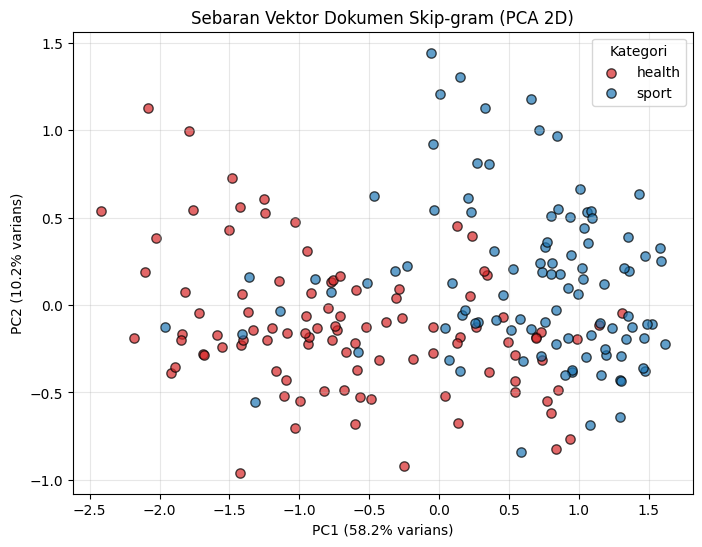

(None, 0, 0, None)

In [11]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for kategori, warna in zip(sorted(set(y)), ['tab:red', 'tab:blue']):
    m = y == kategori
    plt.scatter(X_2d[m, 0], X_2d[m, 1], label=kategori, alpha=0.7, edgecolor='k', s=45, c=warna)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varians)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varians)')
plt.title('Sebaran Vektor Dokumen Skip-gram (PCA 2D)')
plt.legend(title='Kategori')
plt.grid(alpha=0.3)
plt.show()

## 9. Klasifikasi Berita dengan Naive Bayes

Data dibagi **80% latih : 20% uji** (stratified, agar proporsi *health* dan *sport* seimbang di kedua bagian). Classifier yang dipakai adalah **Gaussian Naive Bayes** (`GaussianNB`), karena fitur vektor Skip-gram berupa bilangan real yang bisa bernilai negatif.

In [12]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)
print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Naive Bayes (data uji): {akurasi:.4f} ({akurasi*100:.1f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Data latih: (160, 100) | Data uji: (40, 100)

Akurasi Naive Bayes (data uji): 0.8500 (85.0%)

Classification Report:
              precision    recall  f1-score   support

      health       0.82      0.90      0.86        20
       sport       0.89      0.80      0.84        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



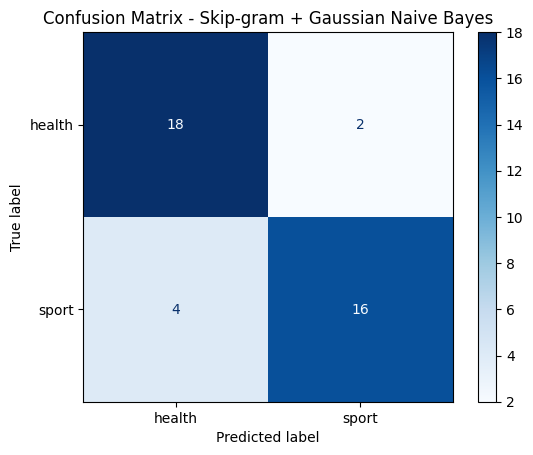

(None, 0, 0, None)

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=nb.classes_)
ConfusionMatrixDisplay(cm, display_labels=nb.classes_).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Skip-gram + Gaussian Naive Bayes')
plt.show()

### Validasi Silang (5-Fold Stratified CV)

Karena datanya hanya 200 berita, akurasi dari satu kali pembagian 80:20 bisa berubah cukup jauh tergantung pembagiannya. Karena itu akurasi juga dihitung dengan **5-fold stratified cross-validation** agar estimasinya lebih stabil. Sebagai pembanding, dicoba juga `MultinomialNB` (yang mensyaratkan fitur non-negatif, sehingga vektor diskalakan ke rentang 0–1 dengan `MinMaxScaler`).

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_uji = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB (MinMaxScaler)': make_pipeline(MinMaxScaler(), MultinomialNB()),
}

hasil_cv = []
for nama, m in model_uji.items():
    skor = cross_val_score(m, X, y, cv=skf, scoring='accuracy')
    hasil_cv.append({'Model': nama,
                     'Akurasi tiap fold': np.round(skor, 3).tolist(),
                     'Rata-rata': round(skor.mean(), 4),
                     'Std': round(skor.std(), 4)})

df_cv = pd.DataFrame(hasil_cv)
df_cv

,Model,Akurasi tiap fold,Rata-rata,Std
0,GaussianNB,"[0.8, 0.775, 0.85, 0.875, 0.825]",0.825,0.0354
1,MultinomialNB (MinMaxScaler),"[0.775, 0.775, 0.85, 0.875, 0.825]",0.820,0.0400


### Hasil Prediksi pada Data Uji

In [15]:
df_hasil = pd.DataFrame({
    'Judul Berita': df_berita.loc[idx_test, 'Judul Berita'].values,
    'Kategori_Asli': y_test,
    'Kategori_Prediksi': y_pred,
    'Benar': y_test == y_pred
})
df_hasil.to_csv('hasil_klasifikasi_naive_bayes.csv', index=False)
print("Tersimpan: 'hasil_klasifikasi_naive_bayes.csv' ->", df_hasil.shape)

salah = df_hasil[~df_hasil['Benar']]
print(f"\nJumlah berita yang salah diklasifikasi: {len(salah)} dari {len(df_hasil)}")
salah if len(salah) > 0 else "Tidak ada - semua benar!"

Tersimpan: 'hasil_klasifikasi_naive_bayes.csv' -> (40, 4)

Jumlah berita yang salah diklasifikasi: 6 dari 40


,Judul Berita,Kategori_Asli,Kategori_Prediksi,Benar
9,"Viral, Ade Rai Bagikan Video Transformasi Mantan Bocah Tergemuk di Dunia",health,sport,False
19,"Pemain RI ke Filipina, PBSI Juga Fokus Antisipasi Virus Corona",sport,health,False
22,"Dampak Corona, Intensitas Latihan David Jacobs Jadi Berkurang",sport,health,False
26,"Waspada Virus Corona, Final Four Proliga Pindah Lokasi dan Tanpa Penonton",sport,health,False
33,BNPB Jamin Tempat Observasi WNI di Pulau Sebaru Lebih Baik dari Natuna,health,sport,False
38,Ini Blunder De Gea yang Bikin Roy Keane Ingin Membunuhnya,sport,health,False


In [16]:
df_hasil.head(10)

,Judul Berita,Kategori_Asli,Kategori_Prediksi,Benar
0,WHO Peringatkan Lonjakan Kasus Corona di Negara yang Longgarkan Lockdown,health,health,True
1,"MotoGP Virtual Race 2: Petrucci Niat Banget Juara, Ini Buktinya",sport,sport,True
2,"Lama di Rumah Saja, Hendra Setiawan Tak Sabar Tanding Lagi",sport,sport,True
3,Man City Juarai Piala Liga Inggris 3 Kali Beruntun,sport,sport,True
4,Bolehkah Kelompok Rentan Terinfeksi Corona Berpuasa Penuh Saat Ramadhan?,health,health,True
5,"Jakarta Banjir, Persiapan Formula E Tetap Jalan",sport,sport,True
6,"Yakin Bisa Kendalikan Corona, Singapura Tak Terapkan Lockdown",health,health,True
7,CdM Jamin Anggaran Pelatnas Olimpiade 2020 Cair Tepat Waktu,sport,sport,True
8,"Video Ketangguhan Penyerang Anyar MU, Odion Ighalo",sport,sport,True
9,"Viral, Ade Rai Bagikan Video Transformasi Mantan Bocah Tergemuk di Dunia",health,sport,False


## 10. Mencoba Prediksi Judul Berita Baru

Judul baru diproses dengan tahapan preprocessing yang sama, diubah menjadi vektor dokumen dari model Skip-gram yang sudah dilatih, lalu diprediksi oleh Naive Bayes. Kata yang tidak ada pada vocabulary model akan diabaikan.

In [17]:
judul_baru = [
    "Vaksin virus corona mulai diuji pada relawan",
    "Timnas Indonesia menang telak di laga persahabatan",
    "Dokter ingatkan bahaya diabetes pada anak",
    "Juara bertahan gagal lolos ke final turnamen",
]

baris = []
for j in judul_baru:
    tokens = preprocessing_token(j)
    vek = vektor_dokumen(tokens, model).reshape(1, -1)
    pred = nb.predict(vek)[0]
    proba = nb.predict_proba(vek)[0]
    baris.append({
        'Judul Baru': j,
        'Token dikenali': [w for w in tokens if w in model.wv],
        'Prediksi': pred,
        'Peluang': dict(zip(nb.classes_, np.round(proba, 3))),
    })

pd.DataFrame(baris)

,Judul Baru,Token dikenali,Prediksi,Peluang
0,Vaksin virus corona mulai diuji pada relawan,"[vaksin, virus, corona]",health,"{'health': 1.0, 'sport': 0.0}"
1,Timnas Indonesia menang telak di laga persahabatan,[indonesia],sport,"{'health': 0.0, 'sport': 1.0}"
2,Dokter ingatkan bahaya diabetes pada anak,"[dokter, ingat, anak]",health,"{'health': 1.0, 'sport': 0.0}"
3,Juara bertahan gagal lolos ke final turnamen,"[juara, lolos, final]",sport,"{'health': 0.0, 'sport': 1.0}"
